CELL 1: IMPORTS & SETUP

In [ ]:
import os
import pandas as pd
import numpy as np
import re
import unicodedata
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CELL 2: LOAD DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

os.environ["WANDB_DISABLED"] = "true"
file_path = '/content/drive/My Drive/MindShield/MindShield_Dataset_9.xlsx'

if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print(f"Dataset Loaded: {df.shape[0]} rows")
    print(f"Columns: {df.columns.tolist()}")
    display(df.head())
else:
    print(f"File not found at {file_path}")

Mounted at /content/drive
Dataset Loaded: 5000 rows
Columns: ['Text', 'Risk_Level']


,Text,Risk_Level
0,eya awilla mata duka witharak ithuru karala ya...,Medium Risk
1,dan masaa hatharak wenawa daala gihin amathaka...,High Risk
2,Daala yanna nam sathekutawath adare karanna ep...,Medium Risk
3,Aluthen jeewitheta ena hama kenama magak awith...,Medium Risk
4,Pana wage adarei kiyala lan wela hitiyata koi ...,Medium Risk


## Preprocessing

CELL 3: ENHANCED NORMALIZATION

In [ ]:
def normalize_sinhala_singlish_v2(text):

    # Enhanced normalization:
    # - Removes stopwords
    # - Preserves script (Sinhala stays Sinhala, Singlish stays Singlish)
    # - Keeps original words for XAI

    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFKC", text.lower())

    # STEP 1: STANDARDIZE VARIANTS
    SINGLISH_VARIANTS = [
        (r"\b(marenne|maranne|marenawa|merenna)\b", "marenna"),
        (r"\b(jeewithe\s*epa|jeewithe\s*epawela)\b", "jeewithe_epa"),
        (r"\b(siyadiwi\s*nasaganna)\b", "siyadiwi_nasaganna"),
        (r"\b(me\s*loken\s*yanna|loken\s*yanna)\b", "loken_yanna"),
        (r"\b(waha\s*kanna)\b", "waha_kanna"),
        (r"\b(jeewath\s*wenna\s*baa|jeewath\s*wenna\s*ba)\b", "jeewath_wenna_baha"),
        (r"\b(daraganna\s*baa|daraganna\s*ba)\b", "daraganna_baha"),
        (r"\b(manasika\s*peedanaya|manasikawa\s*watila)\b", "manasika_peedanaya"),
        (r"\b(papuwa\s*ridenawa|hadawatha\s*ridenawa)\b", "papuwa_ridenawa"),
        (r"\b(waira\s*karanawa)\b", "waira_karanawa"),
        (r"\b(puduma\s*dukak|pudumai\s*dukak|poduma\s*dukak)\b", "puduma_dukak"),
        (r"\b(mage\s*hitha\s*ridena(wa)?|hitha\s*ridena(wa)?)\b", "hitha_ridenawa"),
    ]

    SINHALA_VARIANTS = [
        (r"(මැරෙන්න|මැරෙනවා|මරන්න|මැරුණා)", "මැරෙන්න"),
        (r"ජීවිතේ\s*එපා", "ජීවිතේ_එපා"),
        (r"ජීවිතේම\s*එපා\s*වෙලා", "ජීවිතේ_එපා"),
        (r"සියදිවි\s*නසාගන්න", "සියදිවි_නසාගන්න"),
        (r"ලෝකෙන්\s*යන්න", "ලෝකෙන්_යන්න"),
        (r"වහ\s*කන්න", "වහ_කන්න"),
        (r"වහ\s*කනවා", "වහ_කන්න"),
        (r"ජීවත්\s*වෙන්න\s*බෑ", "ජීවත්_වෙන්න_බෑ"),
        (r"දරාගන්න\s*බෑ", "දරාගන්න_බෑ"),
        (r"දරාගන්න\s*අමාරුයි", "දරාගන්න_බෑ"),
        (r"මානසික\s*පීඩනය", "මානසික_පීඩනය"),
        (r"මානසික\s*පීඩනේක\s*ඉන්නේ", "මානසික_පීඩනය"),
        (r"පීඩනේක\s*ඉන්නේ", "මානසික_පීඩනය"),
        (r"ඔලුව\s*විකාරයි", "ඔලුව_විකාරයි"),
        (r"පපුව\s*රිදෙනවා", "පපුව_රිදෙනවා"),
        (r"හදවත\s*රිදෙනවා", "හදවත_රිදෙනවා"),
        (r"වෛර\s*කරනවා", "වෛර_කරනවා"),
        (r"පුදුම\s*දුකක්", "පුදුම_දුකක්"),
        (r"හිත\s*රිදෙනවා", "හිත_රිදෙනවා"),
    ]

    for pattern, standard in SINGLISH_VARIANTS:
        text = re.sub(pattern, standard, text, flags=re.IGNORECASE)

    for pattern, standard in SINHALA_VARIANTS:
        text = re.sub(pattern, standard, text)

    # STEP 2: STOPWORD REMOVAL
    STOPWORDS = {
        'mama', 'mage', 'mata', 'mawa', 'api', 'ape', 'apiwa', 'oya', 'oyage',
        'oba', 'obage', 'eya', 'eyage', 'eka', 'eyala', 'meka', 'uba', 'ubage',
        'ohu', 'man', 'mam', 'mn', 'mt', 'mge', 'e',
        'මම', 'මට', 'මගේ', 'මාව', 'අපි', 'අපේ', 'ඔබ', 'ඔයා', 'එයා', 'එක', 'මේක',
        'mokakda', 'mokada', 'kawda', 'kohomada', 'kara', 'karanawa', 'gena', 'wena',
        'nisa', 'eth', 'saha', 'da', 'namuth', 'ane', 'wage', 'kiyala', 'ekka',
        'dan', 'ai', 'one', 'thamai', 'dn', 'oni', 'unath', 'hinda', 'ona',
        'නිසා', 'එත්', 'සහ', 'ද', 'නමුත්', 'දැන්', 'වගේ', 'කියලා', 'එක්ක', 'ඕනේ',
    }

    words = [w for w in text.split() if w not in STOPWORDS]
    text = ' '.join(words)

    # STEP 3: CORE NORMALIZATION
    SINGLISH_RULES = [
        (r"\b(ba|baa+|baha)\b", "baha"),
        (r"\b(epa|epaa+)\b", "epa"),
        (r"\b(na|naa)\b", "na"),
        (r"\b(duka|duki)\b", "duka"),
        (r"\b(dukai+|dukak)\b", "dukak"),
        (r"\b(wedana[a-z]*)\b", "wedanawa"),
        (r"\b(riden[a-z]*)\b", "ridenawa"),
        (r"\b(thani[a-z]*)\b", "thani"),
        (r"\b(thanikama[a-z]*)\b", "thanikama"),
        (r"\b(hithenawa|hithenav[a-z]*)\b", "hithenawa"),
        (r"\b(bari|beri)\b", "bari"),
    ]

    SINHALA_RULES = [
        (r"(බෑ|බැ|බැහැ)", "බැහැ"),
        (r"එපා+", "එපා"),
        (r"දුකයි", "දුක"),
        (r"තනියෙන්", "තනි"),
        (r"\bනෙමෙයි\b", "නෙවෙයි"),
        (r"\bමොකක්ද\b", "මොකද්ද"),
        (r"\bකොහොමද\b", "කොහොම"),
    ]

    for pattern, repl in SINGLISH_RULES:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)

    for pattern, repl in SINHALA_RULES:
        text = re.sub(pattern, repl, text)

    # Clean URLs/extra spaces
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"([\U00010000-\U0010ffff])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply normalization
df['clean_text'] = df['Text'].apply(normalize_sinhala_singlish_v2)
print("Enhanced normalization complete")

# Show examples
print("\n" + "="*60)
print("NORMALIZATION EXAMPLES")
print("="*60)
for i in range(min(5, len(df))):
    print(f"Original: {df['Text'].iloc[i][:80]}")
    print(f"Cleaned:  {df['clean_text'].iloc[i][:80]}")
    print("-"*60)

Enhanced normalization complete

NORMALIZATION EXAMPLES
Original: eya awilla mata duka witharak ithuru karala yanawa
Cleaned:  awilla duka witharak ithuru karala yanawa
------------------------------------------------------------
Original: dan masaa hatharak wenawa daala gihin amathaka karanna hithenne na thaama puduma
Cleaned:  masaa hatharak wenawa daala gihin amathaka karanna hithenne na thaama puduma kar
------------------------------------------------------------
Original: Daala yanna nam sathekutawath adare karanna epa kiyala kiyapu yaaluwo.apiwa daal
Cleaned:  daala yanna nam sathekutawath adare karanna epa kiyapu yaaluwo.apiwa daala yanaw
------------------------------------------------------------
Original: Aluthen jeewitheta ena hama kenama magak awith daala yanawa.. Namuth hamadaama t
Cleaned:  aluthen jeewitheta ena hama kenama magak awith daala yanawa.. hamadaama thani da
------------------------------------------------------------
Original: Pana wage adarei kiyala lan wel

CELL 4: DATA CLEANING & AUGMENTATION

In [ ]:
import random

# Remove empty rows
df = df.dropna(subset=['Text', 'Risk_Level'])
df['Risk_Level'] = df['Risk_Level'].astype(str).str.strip()
df = df[df['Risk_Level'].str.lower() != 'nan']
df = df[df['Risk_Level'] != '']

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['Risk_Level'])

# DATA AUGMENTATION
class SimpleAugmenter:
    def __init__(self):
        self.synonyms = {
            'duka': ['dukak', 'dukai'],
            'marenna': ['marila'],
            'thani': ['thanikama'],
            'baha': ['na', 'epa'],
        }

    def synonym_replace(self, text):
        words = text.split()
        new_words = words.copy()

        for i, word in enumerate(words):
            if word in self.synonyms and random.random() > 0.5:
                new_words[i] = random.choice(self.synonyms[word])

        return ' '.join(new_words)

    def random_swap(self, text):
        words = text.split()
        if len(words) >= 2:
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]
        return ' '.join(words)

    def augment(self, text):
        if random.random() > 0.5:
            return self.synonym_replace(text)
        else:
            return self.random_swap(text)

# Augment dataset (focus on High Risk)
augmenter = SimpleAugmenter()
augmented_data = []

for idx, row in df.iterrows():
    # Add original
    augmented_data.append(row.to_dict())

    # Augment High Risk more (2x), others 1x
    num_aug = 2 if row['Risk_Level'] == 'High Risk' else 1

    for _ in range(num_aug):
        aug_row = row.to_dict()
        aug_row['clean_text'] = augmenter.augment(row['clean_text'])
        augmented_data.append(aug_row)

df_augmented = pd.DataFrame(augmented_data)

print("="*60)
print("DATA AUGMENTATION COMPLETE")
print("="*60)
print(f"Original size: {len(df)}")
print(f"Augmented size: {len(df_augmented)}")
print("\nClass distribution:")
print(df_augmented['Risk_Level'].value_counts())

DATA AUGMENTATION COMPLETE
Original size: 4992
Augmented size: 11558

Class distribution:
Risk_Level
High Risk      4722
Medium Risk    3458
No Risk        3378
Name: count, dtype: int64


CELL 5: DATA SPLIT

In [ ]:
# Split the augmented dataset into training and temporary (validation + test) sets
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_augmented['clean_text'],   # Preprocessed Sinhala + Singlish text
    df_augmented['label'],        # Corresponding risk labels
    test_size=0.20,               # 20% reserved for validation + testing
    random_state=42,              # Ensures reproducibility
    stratify=df_augmented['label'] # Maintains class distribution across splits
)

# Further split the temporary set into validation and test sets (50% each)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,                # Split remaining 20% → 10% validation, 10% testing
    random_state=42,
    stratify=temp_labels          # Preserve class balance in both sets
)

# Print dataset sizes to verify correct splitting
print("Data Split Complete:")
print(f"  Training:   {len(train_texts)} samples")
print(f"  Validation: {len(val_texts)} samples")
print(f"  Testing:    {len(test_texts)} samples")

Data Split Complete:
  Training:   9246 samples
  Validation: 1156 samples
  Testing:    1156 samples


CELL 6: TOKENIZATION

In [ ]:
# Import required components from HuggingFace Transformers and PyTorch
from transformers import DataCollatorWithPadding, AutoTokenizer
import torch, numpy as np

# Load pretrained tokenizer for XLM-RoBERTa (supports multilingual text including Sinhala)
model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Define maximum sequence length for input text
MAX_LEN = 128

# Function to tokenize text data
def tokenize_texts(texts):
    return tokenizer(
        list(texts),           # Convert input texts to list format
        truncation=True,       # Truncate long sequences
        max_length=MAX_LEN     # Limit input length to 128 tokens
    )

# Apply tokenization to train, validation, and test datasets
train_encodings = tokenize_texts(train_texts)
val_encodings   = tokenize_texts(val_texts)
test_encodings  = tokenize_texts(test_texts)

# Custom PyTorch Dataset class for handling tokenized data
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings

        # Convert labels to numpy array (ensures compatibility)
        self.labels = labels.to_numpy() if hasattr(labels, "to_numpy") else np.array(labels)

    def __getitem__(self, idx):
        # Convert each encoding (input_ids, attention_mask, etc.) into tensors
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

        # Add corresponding label for each sample
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        # Return total number of samples
        return len(self.labels)

# Create dataset objects for training, validation, and testing
train_dataset = MentalHealthDataset(train_encodings, train_labels)
val_dataset   = MentalHealthDataset(val_encodings, val_labels)
test_dataset  = MentalHealthDataset(test_encodings, test_labels)

# Data collator dynamically pads batches during training (efficient memory usage)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization complete")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenization complete


CELL 7: MODEL TRAINING

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

# Select GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Get number of output classes from label encoder
num_labels = len(le.classes_)

# Compute class weights to reduce bias toward majority classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels.values
)

# Convert class weights to tensor and move to selected device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights: {class_weights}")

# Custom Trainer class that uses weighted cross-entropy loss
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):
        # Extract labels from batch inputs
        labels = inputs.pop("labels")

        # Forward pass through the model
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply weighted loss to handle class imbalance
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# Load pretrained XLM-RoBERTa model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
).to(device)

# Increase dropout rates to improve regularization and reduce overfitting
model.config.hidden_dropout_prob = 0.25
model.config.attention_probs_dropout_prob = 0.25

# Define evaluation metrics used during validation
def compute_metrics_v2(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        "accuracy": accuracy_score(labels, preds),                      # Overall correctness
        "f1_macro": f1_score(labels, preds, average="macro"),          # Equal importance to all classes
        "f1_weighted": f1_score(labels, preds, average="weighted"),    # Weighted by class frequency
    }

# Configure training process
training_args = TrainingArguments(
    output_dir='/content/drive/My Drive/MindShield/checkpoints',

    # Train for more epochs to allow better learning
    num_train_epochs=8,

    # Batch configuration
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,   # Simulates larger batch size

    # Learning rate and scheduler settings
    learning_rate=1.2e-5,
    lr_scheduler_type="cosine_with_restarts",
    warmup_ratio=0.1,

    # Regularization settings
    weight_decay=0.02,
    max_grad_norm=0.5,

    # Evaluate and save model after each epoch
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,

    # Speed and efficiency
    fp16=True,
    dataloader_num_workers=2,

    # Logging settings
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    seed=42,
)

# Create trainer with weighted loss and early stopping
trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_v2,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,      # Stop if no improvement for 2 evaluations
            early_stopping_threshold=0.001  # Minimum improvement threshold
        )
    ]
)

# Start the training process
print("\n" + "="*50)
print("STARTING IMPROVED TRAINING")
print("="*50)
trainer.train()

# Print path of the best saved checkpoint
print(f"\nBest checkpoint: {trainer.state.best_model_checkpoint}")

Class Weights: tensor([0.8158, 1.1142, 1.1406], device='cuda:0')


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



STARTING IMPROVED TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.083300,1.109101,0.314879,0.282585,0.292554
2,0.915100,0.856703,0.625433,0.577128,0.591064
3,0.665200,0.572466,0.770761,0.771909,0.776266
4,0.526800,0.427604,0.836505,0.829575,0.836317
5,0.368400,0.376710,0.869377,0.864727,0.869995
6,0.281000,0.329604,0.885813,0.878091,0.884101
7,0.228600,0.302718,0.894464,0.889800,0.894512
8,0.187300,0.303851,0.894464,0.889480,0.894220



Best checkpoint: /content/drive/My Drive/MindShield/checkpoints/checkpoint-2023


CELL 8: EVALUATION


EVALUATING ON TEST SET


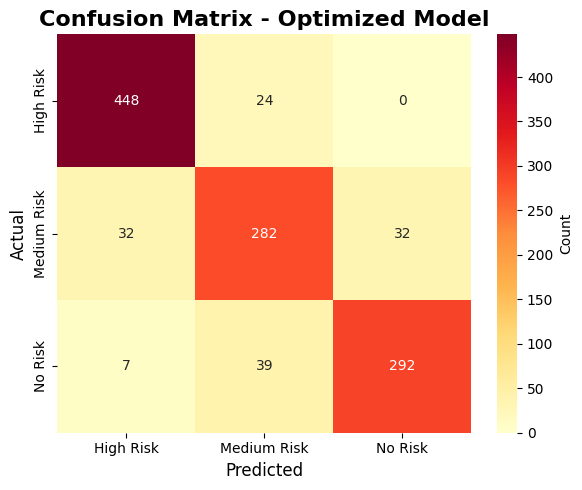


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   High Risk     0.9199    0.9492    0.9343       472
 Medium Risk     0.8174    0.8150    0.8162       346
     No Risk     0.9012    0.8639    0.8822       338

    accuracy                         0.8841      1156
   macro avg     0.8795    0.8760    0.8776      1156
weighted avg     0.8838    0.8841    0.8837      1156


PER-CLASS BREAKDOWN
High Risk       Accuracy: 0.9492
Medium Risk     Accuracy: 0.8150
No Risk         Accuracy: 0.8639


In [ ]:
print("\n" + "="*50)
print("EVALUATING ON TEST SET")
print("="*50)

test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Optimized Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(test_labels, test_preds,
                          target_names=le.classes_,
                          digits=4))

# Per-class metrics
print("\n" + "="*50)
print("PER-CLASS BREAKDOWN")
print("="*50)
for i, label in enumerate(le.classes_):
    mask = test_labels == i
    class_acc = accuracy_score(test_labels[mask], test_preds[mask])
    print(f"{label:15} Accuracy: {class_acc:.4f}")

In [ ]:
import torch.nn.functional as F

def predict_risk(text):
    # 1. Preprocess using your actual function from the notebook
    try:
        # Based on your notebook, the function is named 'advanced_normalize'
        clean_input = advanced_normalize(text)
    except NameError:
        # Fallback if the function isn't found
        clean_input = text.lower().strip()

    # 2. Tokenize
    inputs = tokenizer(clean_input, return_tensors="pt", truncation=True, max_length=128, padding=True).to(device)

    # 3. Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        confidence, predicted_class_id = torch.max(probs, dim=1)

    # 4. Map ID back to Label name
    predicted_label = le.inverse_transform([predicted_class_id.item()])[0]

    print(f"Input: {text[:100]}..." if len(text) > 100 else f"Input: {text}")
    print(f"Prediction: {predicted_label} ({confidence.item()*100:.2f}% confidence)")
    print("-" * 30)

# --- TEST IT HERE ---
print("="*60)
print("CUSTOM SENTENCE TESTING")
print("="*60)

predict_risk("මනරම් රැඟුමින්, සොඳුරු සිනහවෙන් රිදී තිරය හැඩ කළ සප්ත කන්‍යාවිය,'තාරා' ලෙසින් නැවතත්.... 💞✨ආදරණීය අත්දැකීමක් විඳගන්න සූදානම් වෙන්න.")

predict_risk("පිරිමි ළමෙක් මට එයා ගැන කැමැත්තක් ඇති කරලා මගේ පස්සෙන් ඇවිත් අන්තිමේදී අපි යාලුවෝ විතරයි කිව්වා... මන් තනියෙන්. මන් දන්නේ නෑ මොකද්ද අඩුපාඩුව මගේ කියලා ඒක පාර එපා උන. ඇයි මන් මේ තරම් තනි වෙන්නේ. මන් හරි දුකෙන් ඉන්නේ, .")

predict_risk("mn loku manasika peedaneka inne")

predict_risk("mewa dakiddi sathutu kandulu enwa nikanma, hari santhosai")

CUSTOM SENTENCE TESTING
Input: මනරම් රැඟුමින්, සොඳුරු සිනහවෙන් රිදී තිරය හැඩ කළ සප්ත කන්‍යාවිය,'තාරා' ලෙසින් නැවතත්.... 💞✨ආදරණීය අත...
Prediction: No Risk (99.84% confidence)
------------------------------
Input: පිරිමි ළමෙක් මට එයා ගැන කැමැත්තක් ඇති කරලා මගේ පස්සෙන් ඇවිත් අන්තිමේදී අපි යාලුවෝ විතරයි කිව්වා... ම...
Prediction: Medium Risk (98.41% confidence)
------------------------------
Input: mn loku manasika peedaneka inne
Prediction: High Risk (99.92% confidence)
------------------------------
Input: mewa dakiddi sathutu kandulu enwa nikanma, hari santhosai
Prediction: No Risk (99.56% confidence)
------------------------------


CELL 9: SAVE MODEL

In [ ]:
import json
import pickle

project_folder = '/content/drive/My Drive/MindShield/'
model_save_path = os.path.join(project_folder, 'MindShield_Final_Model(88)')

# Save model
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label encoder
with open(os.path.join(model_save_path, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

# Save metrics
final_metrics = {
    "test_accuracy": accuracy_score(test_labels, test_preds),
    "test_f1": f1_score(test_labels, test_preds, average='weighted'),
    "classification_report": classification_report(test_labels, test_preds,
                                                  target_names=le.classes_,
                                                  output_dict=True)
}

with open(os.path.join(model_save_path, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=4)

print("\n" + "="*50)
print("MODEL SAVED SUCCESSFULLY")
print("="*50)
print(f"Location: {model_save_path}")
print(f"Test Accuracy: {final_metrics['test_accuracy']:.4f}")
print(f"Test F1 Score: {final_metrics['test_f1']:.4f}")
print("="*50)


MODEL SAVED SUCCESSFULLY
Location: /content/drive/My Drive/MindShield/MindShield_Final_Model(88)
Test Accuracy: 0.8841
Test F1 Score: 0.8837
